# Eksplorasi Listing Produk Tokopedia

Notebook ini adalah **proses di balik** [Product Intelligence Dashboard](../app.py). Dashboard menampilkan hasil akhir; notebook ini menunjukkan bagaimana hasil itu didapat — termasuk kesalahan yang ditemukan di tengah jalan.

Strukturnya mengikuti lima saran eksplorasi dari halaman dataset di Kaggle, tapi urutannya diubah: **pembersihan data dikerjakan paling awal**, karena semua analisis lain bergantung padanya.

| Bagian | Saran Kaggle |
|---|---|
| 1. Pembersihan data | #5 Data Cleaning Challenge |
| 2. Sebaran harga per kategori | #1 Exploratory Data Analysis |
| 3. Analisis geografis | #2 Geographical Analysis |
| 4. Diskon, rating, dan penjualan | #3 Sales Performance |
| 5. Kata kunci di nama produk | #4 Market Trends |
| 6. Dari eksplorasi ke skor peluang | — (jembatan ke dashboard) |

**Dataset:** [Indonesia E-Commerce Dataset: Tokopedia Listings](https://www.kaggle.com/datasets/pandaa12/indonesia-e-commerce-dataset-tokopedia-listings) — 29.519 listing, lisensi Apache 2.0.

Semua fungsi pengolahan diimpor dari folder `src/`, **bukan ditulis ulang di sini**, supaya angka di notebook dan dashboard selalu sama.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src import clean_listings
from src import plot_style as ps
from src.config import CATEGORY_KEYWORDS, LISTINGS_RAW

ps.terapkan()
pd.set_option("display.max_colwidth", 70)

mentah = pd.read_csv(LISTINGS_RAW)
print(f"{mentah.shape[0]:,} baris, {mentah.shape[1]} kolom")
mentah.head()

29,519 baris, 9 kolom


,Nama Produk,Nama Toko,Lokasi Toko,Terjual,Jumlah Ulasan,Rating,Harga (IDR),Diskon (%),Produk URL
0,Raw Food Beef Bone-In / Daging Giling / Dog Food / Cat Food,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0,35000,0.0,https://www.tokopedia.com/lazy-dog-supply/raw-food-beef-bone-in-da...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun Raw Dog Cat Food,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0,79999,0.0,https://www.tokopedia.com/rumahbully/turkey-meat-only-no-bone-1kg-...
2,Chicken mix Salmon Raw Food ayam mix salmon makanan kucing anjing ...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0,33000,0.0,https://www.tokopedia.com/rumahbully/chicken-mix-salmon-raw-food-a...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG FOOD 1KG,RumahBully,Tangerang Selatan,100+ terjual,NaN,5.0,29900,0.0,https://www.tokopedia.com/rumahbully/promo-bulanan-sosis-chop-prem...
4,Premium Dog Food / Daging Sapi Giling / Raw Food Beef Bone-In PLUS...,RumahBully,Jakarta Selatan,1rb+ terjual,NaN,5.0,39000,0.0,https://www.tokopedia.com/rumahbully/premium-dog-food-daging-sapi-...


## 1. Pembersihan data

Sekilas datanya terlihat rapi. Tapi tiga kolom yang seharusnya berupa angka atau nama kota ternyata berisi teks bebas:

In [2]:
for kolom in ["Terjual", "Jumlah Ulasan", "Lokasi Toko"]:
    contoh = mentah[kolom].dropna().sample(6, random_state=3).tolist()
    print(f"{kolom:14} {contoh}")

Terjual        ['16 terjual', '3 terjual', '2 terjual', '7 rb+ terjual', '2 terjual', '0 terjual']
Jumlah Ulasan  ['6rb+ ulasan', '10 ulasan', '1 ulasan', '0 ulasan', '0 ulasan', '0 ulasan']
Lokasi Toko    ['Kota Tangerang', 'Palembang', 'Kota Bandar Lampung', 'Kota Depok', 'Bekasi', 'Indonesia']


### 1a. Mengubah "1rb+ terjual" menjadi angka

Tokopedia tidak menampilkan jumlah terjual yang pasti, melainkan **bertingkat**: "100+", "250+", "1rb+". Maka hasil konversinya adalah **batas bawah** — "1rb+" berarti minimal 1.000, bisa jadi 1.900. Keterbatasan ini dibawa terus sampai kesimpulan akhir.

Pola teks yang muncul di kolom `Terjual` (angka diganti huruf `N`):

In [3]:
pola = mentah["Terjual"].dropna().str.replace(r"\d+(?:[.,]\d+)?", "N", regex=True)
pola.value_counts().head(6).to_frame("jumlah baris")

,jumlah baris
Terjual,
N terjual,12196
N+ terjual,11709
Nrb+ terjual,4561
N rb+ terjual,176
N+ Terjual,121
N Terjual,117


In [4]:
contoh = ["26 terjual", "250+ terjual", "1rb+ terjual", "1,2rb+ terjual", "10rb+ terjual", "10 ulasan"]
pd.DataFrame({"teks asli": contoh, "hasil": [clean_listings.parse_terjual(c) for c in contoh]})

,teks asli,hasil
0,26 terjual,26.0
1,250+ terjual,250.0
2,1rb+ terjual,1000.0
3,"1,2rb+ terjual",1200.0
4,10rb+ terjual,10000.0
5,10 ulasan,10.0


Satu jebakan kecil di kolom `Jumlah Ulasan`: nilai kosong **bukan berarti nol ulasan**. Produk dengan jumlah ulasan kosong tetap punya rating — artinya angkanya hanya tidak ditampilkan. Jadi nilai kosong dibiarkan kosong, tidak diisi 0.

Sekarang seluruh pembersihan dijalankan lewat fungsi yang sama dengan pipeline dashboard:

In [5]:
df = clean_listings.bersihkan()

[listings] 29,484 baris bersih (35 dibuang karena harga tidak valid)
[listings] 151 produk dipangkas nilainya; total nilai pasar turun 72%
[listings] sebaran kategori:
kategori
lainnya              7312
fashion              6534
rumah tangga         4592
elektronik           3424
kecantikan           2581
makanan & minuman    1533
handphone             916
buku & alat tulis     587
olahraga              489
pertukangan           440
ibu & bayi            408
otomotif              390
hewan peliharaan      278


### 1b. Kategori dari nama produk — dan bug yang tidak memunculkan error

Dataset ini **tidak punya kolom kategori**, jadi kategori diturunkan dari nama produk lewat kata kunci. Setiap kata kunci diberi bobot sepanjang hurufnya, sehingga frasa spesifik menang: "sepatu bola" (olahraga) mengalahkan "sepatu" (fashion).

Versi pertama mencocokkan kata kunci sebagai **potongan huruf**. Kodenya berjalan tanpa error dan hasilnya terlihat wajar. Masalahnya baru ketahuan setelah contoh-contoh produknya dibaca satu per satu. Berikut perbandingan versi pertama dengan versi sekarang, memakai daftar kata kunci yang sama persis:

In [6]:
def kategori_potongan_huruf(nama):
    teks = str(nama).lower()
    skor = {}
    for kategori, kata_kunci in CATEGORY_KEYWORDS.items():
        total = sum(len(k) for k in kata_kunci if k in teks)
        if total:
            skor[kategori] = total
    return max(skor, key=skor.get) if skor else "lainnya"

versi_awal = df["nama_produk"].apply(kategori_potongan_huruf)
berubah = versi_awal != df["kategori"]
print(f"Produk yang kategorinya berbeda: {berubah.sum():,} ({berubah.mean():.1%})")

perbandingan = pd.DataFrame({
    "versi awal (potongan huruf)": versi_awal.value_counts(),
    "versi sekarang (kata utuh)": df["kategori"].value_counts(),
})
perbandingan["selisih"] = perbandingan.iloc[:, 0] - perbandingan.iloc[:, 1]
perbandingan.sort_values("selisih", ascending=False)

Produk yang kategorinya berbeda: 2,789 (9.5%)


,versi awal (potongan huruf),versi sekarang (kata utuh),selisih
pertukangan,1469,440,1029
otomotif,777,390,387
kecantikan,2952,2581,371
makanan & minuman,1726,1533,193
rumah tangga,4784,4592,192
fashion,6697,6534,163
elektronik,3499,3424,75
handphone,936,916,20
hewan peliharaan,280,278,2
olahraga,486,489,-3


In [7]:
salah = df[(versi_awal == "pertukangan") & (df["kategori"] != "pertukangan")]
salah[["nama_produk", "kategori"]].head(8)

,nama_produk,kategori
91,HOTSHOW Handsock Manset Tangan Jempol Muslimah Manset Tangan Hands...,lainnya
93,Manset Lengan Panjang Manset Tangan Silver 48cm sie XL-65513005.01,lainnya
98,Manset Tangan Pendek,lainnya
101,Manset Tangan Jumbo/ Deker Tangan Jumbo,lainnya
103,MANSET TANGAN SAMBUNG BALERO JUMBO SPANDEK,lainnya
104,Manset Tangan Bolero Sambung Lengan Panjang Bahan Rayon Premium,lainnya
105,Lintang Handsock - Manset Tangan Jempol - Elmika Hijrah,lainnya
107,DISKON handsock jempol / manset jempol polos / handsock murah,lainnya


Kata kunci `"tang"` (alat pertukangan) cocok dengan "Manset **Tang**an", dan `"mur"` (mur dan baut) cocok dengan "**mur**ah". Akibatnya kategori pertukangan menggelembung lebih dari tiga kali lipat, dan hampir satu dari sepuluh produk salah kategori.

Perbaikannya — mencocokkan **kata utuh** — punya harga: aturannya lebih ketat, sehingga produk berkategori "lainnya" bertambah. Trade-off ini disengaja. Produk yang *salah* kategori merusak analisis; produk yang *tidak* terkategori hanya tidak ikut dihitung.

Sebaran kategori akhir:

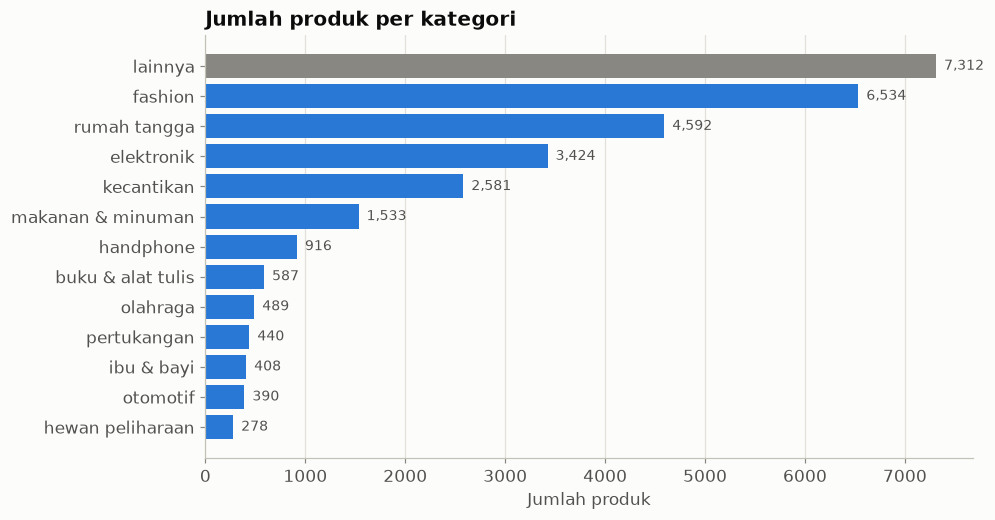

Tak terklasifikasi: 24.8%


In [8]:
jumlah = df["kategori"].value_counts().sort_values()
warna = [ps.MUTED if k == "lainnya" else ps.BIRU for k in jumlah.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(jumlah.index, jumlah.values, color=warna)
for i, v in enumerate(jumlah.values):
    ax.text(v + 80, i, f"{v:,}", va="center", color=ps.INK_2, fontsize=9)
ax.set_title("Jumlah produk per kategori")
ax.set_xlabel("Jumlah produk")
plt.show()
print(f"Tak terklasifikasi: {(df['kategori'] == 'lainnya').mean():.1%}")

Lima kategori pertama (fashion, elektronik, handphone, olahraga, pertukangan) mengikuti taksonomi dataset ulasan yang dipakai di notebook 02. Tujuh sisanya ditambahkan setelah melihat isi kategori "lainnya": ternyata dataset ini adalah marketplace umum yang juga berisi perabot rumah, kosmetik, makanan, dan produk bayi.

### 1c. Outlier: satu listing mobil menguasai separuh nilai pasar

Nilai pasar diperkirakan dari **harga × jumlah terjual**. Begitu dihitung, ada yang janggal:

In [9]:
total_mentah = df["estimasi_omzet_mentah"].sum()
teratas = df.nlargest(5, "estimasi_omzet_mentah")[["nama_produk", "harga", "terjual", "estimasi_omzet_mentah"]].copy()
teratas["porsi dari total"] = (teratas["estimasi_omzet_mentah"] / total_mentah).map("{:.1%}".format)
teratas

,nama_produk,harga,terjual,estimasi_omzet_mentah,porsi dari total
887,Hyundai Palisade Signature 4x2,900000000.0,9730.0,8.757000e+12,51.4%
16706,Semen Jakarta @40kg FREE ONGKIR PCC SNI,10700000.0,50000.0,5.350000e+11,3.1%
7842,Mitsubishi Pajero Sport Dakar (4x2) AT - 400JT Cicil 0% 3x,400000000.0,750.0,3.000000e+11,1.8%
11874,"Kalung Olivia - 2,66 gr [GE-1084318] By Ubs",5249000.0,31000.0,1.627190e+11,1.0%
7826,Mitsubishi Pajero Sport Dakar (4x2) AT - 200JT,200000000.0,750.0,1.500000e+11,0.9%


Sebuah mobil seharga Rp900 juta tercatat terjual ribuan unit — hampir pasti listing uang muka atau data yang keliru. Satu baris ini saja menguasai lebih dari separuh total nilai pasar.

Membuang baris seperti ini satu per satu tidak bisa dipertanggungjawabkan, karena batas "janggal" jadi subjektif. Yang dipakai adalah **winsorizing**: nilai per produk dipangkas di persentil 99,5 *di dalam kategorinya masing-masing*. Outlier tidak dibuang, hanya dibatasi.

In [10]:
def porsi_10_teratas(kolom):
    return df[kolom].nlargest(10).sum() / df[kolom].sum()

print(f"Produk yang dipangkas         : {df['dipangkas'].sum():,} ({df['dipangkas'].mean():.1%})")
print(f"Porsi 10 produk teratas, awal : {porsi_10_teratas('estimasi_omzet_mentah'):.1%}")
print(f"Porsi 10 produk teratas, akhir: {porsi_10_teratas('estimasi_omzet'):.1%}")

Produk yang dipangkas         : 151 (0.5%)
Porsi 10 produk teratas, awal : 61.9%
Porsi 10 produk teratas, akhir: 4.6%


## 2. Sebaran harga per kategori

*Saran Kaggle #1: Analyze the distribution of prices across different product categories.*

Harga sangat miring ke kanan — sedikit produk sangat mahal — sehingga sumbunya memakai skala logaritma. Kotak menunjukkan 50% produk di tengah, garis tebal adalah median, dan garis tipis menjangkau persentil 5 sampai 95.

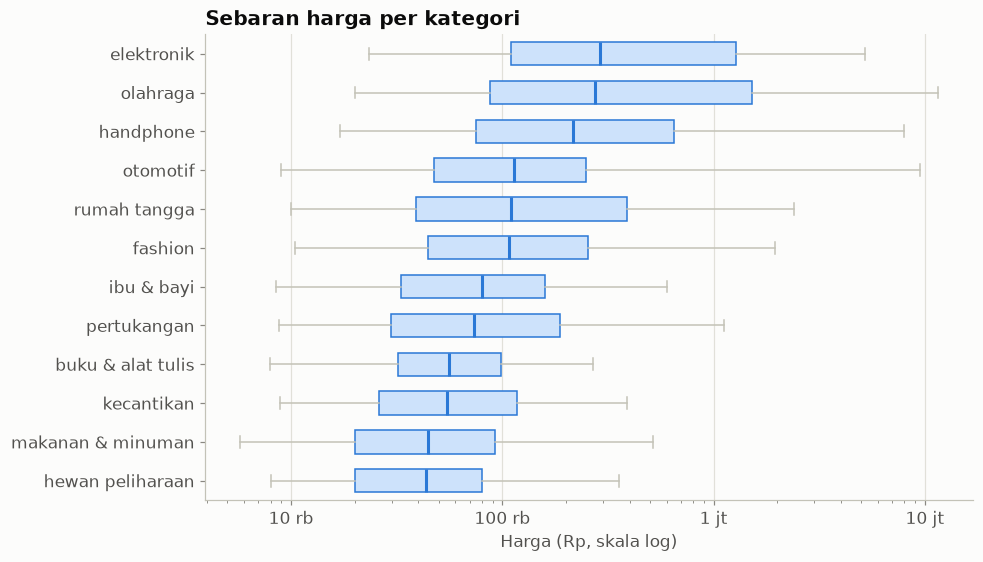

,kuartil bawah,median,kuartil atas
kategori,,,
hewan peliharaan,Rp20 rb,Rp44 rb,Rp80 rb
makanan & minuman,Rp20 rb,Rp45 rb,Rp92 rb
kecantikan,Rp26 rb,Rp55 rb,Rp117 rb
buku & alat tulis,Rp32 rb,Rp56 rb,Rp98 rb
pertukangan,Rp30 rb,Rp73 rb,Rp187 rb
ibu & bayi,Rp33 rb,Rp80 rb,Rp160 rb
fashion,Rp44 rb,Rp108 rb,Rp255 rb
rumah tangga,Rp39 rb,Rp110 rb,Rp390 rb
otomotif,Rp47 rb,Rp113 rb,Rp250 rb


In [11]:
k = df[df["kategori"] != "lainnya"]
urutan = k.groupby("kategori")["harga"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(
    [k.loc[k["kategori"] == c, "harga"] for c in urutan],
    orientation="horizontal", tick_labels=urutan, showfliers=False, widths=0.6, whis=(5, 95),
    patch_artist=True,
    boxprops=dict(facecolor=ps.SEQ_BLUE[0], edgecolor=ps.BIRU),
    medianprops=dict(color=ps.BIRU, linewidth=2),
    whiskerprops=dict(color=ps.AXIS), capprops=dict(color=ps.AXIS),
)
ax.set_xscale("log")
ax.set_xticks([1e4, 1e5, 1e6, 1e7])
ax.set_xticklabels(["10 rb", "100 rb", "1 jt", "10 jt"])
ax.set_title("Sebaran harga per kategori")
ax.set_xlabel("Harga (Rp, skala log)")
plt.show()

(k.groupby("kategori")["harga"].quantile([0.25, 0.5, 0.75]).unstack()
   .rename(columns={0.25: "kuartil bawah", 0.5: "median", 0.75: "kuartil atas"})
   .sort_values("median").map(ps.rupiah))

**Temuan:**

- Harga median antar kategori berbeda hampir **tujuh kali lipat** — dari sekitar Rp44 ribu (hewan peliharaan, makanan) hingga Rp291 ribu (elektronik).
- Di dalam satu kategori pun rentangnya lebar. Di olahraga, kuartil atas (Rp1,5 juta) sekitar 17 kali kuartil bawah (Rp87 ribu) — raket murah dan sepeda mahal ada di kategori yang sama.

**Implikasi untuk dashboard:** segmen harga *tidak boleh* dibuat dengan batas global. Kalau batas "Premium" berlaku sama untuk semua kategori, hampir semua elektronik jatuh ke Premium dan hampir semua makanan ke Ekonomis. Karena itu segmen dihitung dengan **kuartil di dalam tiap kategori**.

## 3. Analisis geografis

*Saran Kaggle #2: Visualize which cities or regions have the most active sellers or the highest sales volume.*

Dua penyesuaian lokasi dari tahap pembersihan dipakai di sini: variasi penulisan Jakarta ("Dki Jakarta", "Pancoran, Kota Jakarta Selatan") digabung jadi **DKI Jakarta**, dan toko berlokasi "Indonesia" — yang bukan nama kota — dianggap tidak diketahui.

Lokasi tidak diketahui: 10.1% produk


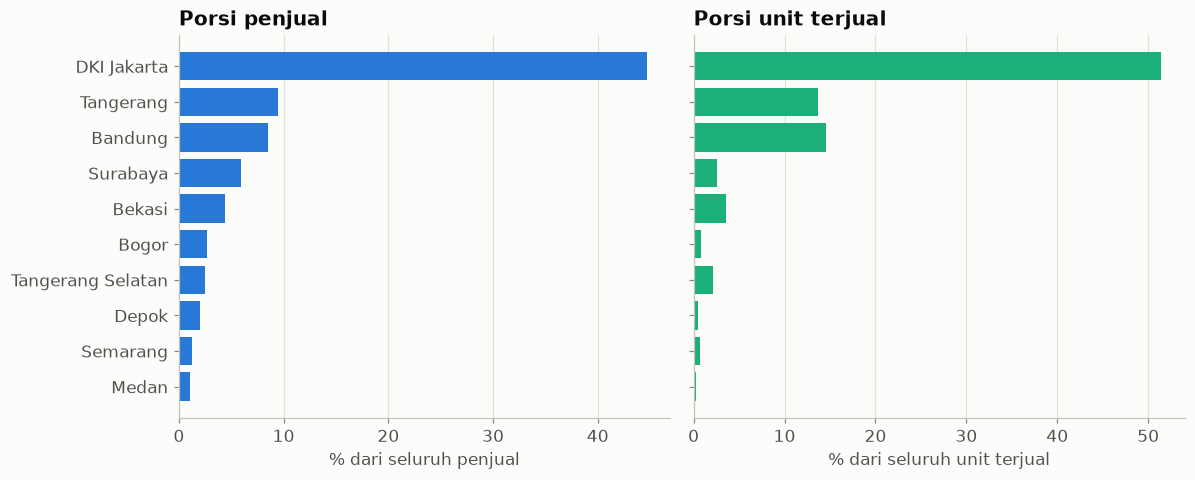

Jabodetabek: 66% penjual, 72% unit terjual


,penjual,porsi penjual,porsi terjual
wilayah,,,
DKI Jakarta,6540,44.7%,51.4%
Tangerang,1384,9.5%,13.7%
Bandung,1243,8.5%,14.5%
Surabaya,862,5.9%,2.6%
Bekasi,647,4.4%,3.6%
Bogor,386,2.6%,0.8%
Tangerang Selatan,360,2.5%,2.2%
Depok,295,2.0%,0.5%
Semarang,180,1.2%,0.7%


In [12]:
print(f"Lokasi tidak diketahui: {(df['wilayah'] == 'Tidak Diketahui').mean():.1%} produk")

w = df[df["wilayah"] != "Tidak Diketahui"]
geo = w.groupby("wilayah").agg(penjual=("nama_toko", "nunique"), terjual=("terjual", "sum"))
geo["porsi penjual"] = geo["penjual"] / geo["penjual"].sum()
geo["porsi terjual"] = geo["terjual"] / geo["terjual"].sum()
top = geo.sort_values("penjual", ascending=False).head(10)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
y = top.index[::-1]
a1.barh(y, top["porsi penjual"][::-1] * 100, color=ps.BIRU)
a1.set_title("Porsi penjual")
a1.set_xlabel("% dari seluruh penjual")
a2.barh(y, top["porsi terjual"][::-1] * 100, color=ps.HIJAU)
a2.set_title("Porsi unit terjual")
a2.set_xlabel("% dari seluruh unit terjual")
plt.tight_layout()
plt.show()

jabo = ["DKI Jakarta", "Tangerang", "Tangerang Selatan", "Bekasi", "Bogor", "Depok"]
g = geo[geo.index.isin(jabo)]
print(f"Jabodetabek: {g['porsi penjual'].sum():.0%} penjual, {g['porsi terjual'].sum():.0%} unit terjual")
top[["penjual", "porsi penjual", "porsi terjual"]].style.format({"porsi penjual": "{:.1%}", "porsi terjual": "{:.1%}"})

**Temuan:**

- Pasar sangat terpusat: **DKI Jakarta saja** menampung sekitar 45% penjual dan 51% unit terjual. Ditambah kota sekitarnya, Jabodetabek mencapai dua pertiga penjual.
- **Bandung menonjol**: hanya 8,5% penjual, tapi menyumbang 14,5% unit terjual — penjual Bandung rata-rata jauh lebih produktif per toko.
- Kebalikannya **Surabaya**: 5,9% penjual, tapi hanya 2,6% unit terjual.

**Catatan kehati-hatian:** ini sampel hasil scraping, bukan sensus. Dominasi Jakarta bisa sebagian mencerminkan cara data dikumpulkan — misalnya urutan hasil pencarian Tokopedia — bukan hanya kondisi pasar. Selain itu sekitar 10% produk tidak punya lokasi yang jelas.

## 4. Diskon, rating, dan penjualan

*Saran Kaggle #3: Investigate the correlation between Rating, Diskon (%), and Terjual. Do higher discounts always lead to more sales?*

Mulai dari pertanyaan paling langsung: apakah produk berdiskon lebih laku?

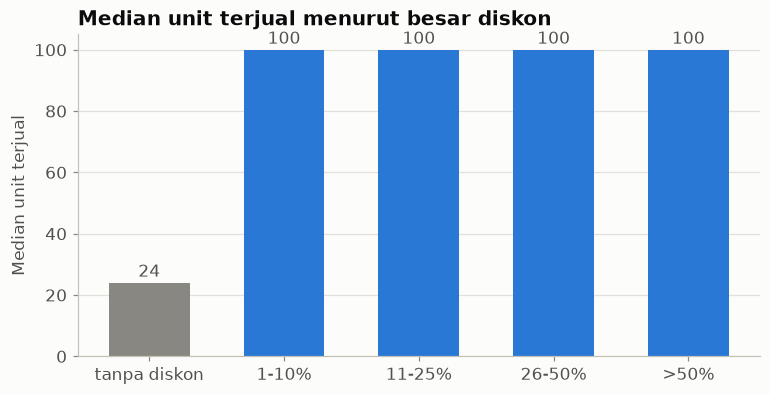

Produk berdiskon: 34.5%


,jumlah produk,median terjual
kelompok diskon,,
tanpa diskon,19308,24.0
1-10%,2464,100.0
11-25%,2018,100.0
26-50%,3273,100.0
>50%,2421,100.0


In [13]:
df["kelompok diskon"] = pd.cut(df["diskon"], [-0.1, 0, 10, 25, 50, 100],
                               labels=["tanpa diskon", "1-10%", "11-25%", "26-50%", ">50%"])
ringkas = df.groupby("kelompok diskon", observed=True)["terjual"].agg(["count", "median"])

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(ringkas.index.astype(str), ringkas["median"], color=[ps.MUTED] + [ps.BIRU] * 4, width=0.6)
for i, v in enumerate(ringkas["median"]):
    ax.text(i, v + 2, f"{v:.0f}", ha="center", color=ps.INK_2)
ax.set_title("Median unit terjual menurut besar diskon")
ax.set_ylabel("Median unit terjual")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.show()

print(f"Produk berdiskon: {(df['diskon'] > 0).mean():.1%}")
ringkas.rename(columns={"count": "jumlah produk", "median": "median terjual"})

Produk berdiskon punya median penjualan sekitar **empat kali** produk tanpa diskon (100 vs 24 unit). Tapi yang lebih menarik: **besar diskonnya tidak membuat perbedaan** — diskon 5% dan 60% sama-sama di median 100.

Sebelum menyimpulkan, ada dua hal yang harus diperiksa.

**Pertama, apakah pola ini hanya karena campuran kategori?** Misalnya kalau kosmetik — yang memang laris — kebetulan sering didiskon. Maka perbandingannya diulang *di dalam* tiap kategori:

In [14]:
per_kategori = (df[df["kategori"] != "lainnya"]
                .assign(berdiskon=lambda d: np.where(d["diskon"] > 0, "berdiskon", "tanpa diskon"))
                .groupby(["kategori", "berdiskon"])["terjual"].median().unstack())
per_kategori["rasio"] = per_kategori["berdiskon"] / per_kategori["tanpa diskon"]
per_kategori.sort_values("rasio", ascending=False).round(1)

berdiskon,berdiskon,tanpa diskon,rasio
kategori,,,
kecantikan,500.0,50.0,10.0
buku & alat tulis,100.0,11.0,9.1
otomotif,80.0,11.0,7.3
elektronik,100.0,16.0,6.2
ibu & bayi,100.0,19.0,5.3
fashion,90.0,18.0,5.0
pertukangan,70.0,16.0,4.4
rumah tangga,100.0,26.0,3.8
handphone,60.0,20.0,3.0


Polanya bertahan di hampir semua kategori, jadi bukan efek campuran.

**Kedua, keterbatasan kolom terjual.** Karena angkanya bertingkat ("100+", "250+"), median cenderung "menempel" di angka-angka tingkat itu. "Semua kelompok diskon bermedian 100" sebagian adalah efek pembulatan ini — resolusinya terlalu kasar untuk membedakan diskon 10% dan 50%.

**Yang tidak boleh disimpulkan:** bahwa diskon *menyebabkan* penjualan naik. Ini data observasi, bukan eksperimen. Penjelasan lain sama masuknya: penjual yang rajin memasang diskon mungkin memang toko yang lebih aktif dan mapan, atau produk berdiskon lebih sering ditampilkan oleh Tokopedia. Kesimpulan yang aman: *diskon adalah ciri umum produk laris*, bukan *diskon membuat produk laris*.

Sekarang hubungan antar semua variabel sekaligus. Korelasi Spearman dipakai karena data sangat miring dan bertingkat — yang diukur adalah urutan, bukan selisih angka:

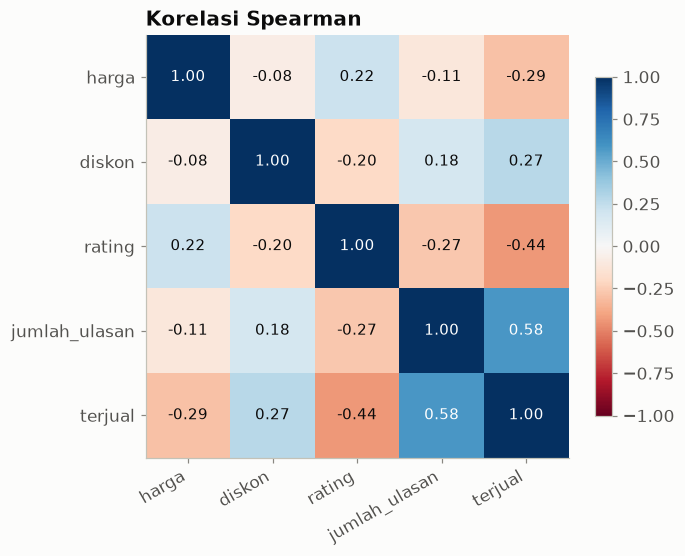

In [15]:
kolom = ["harga", "diskon", "rating", "jumlah_ulasan", "terjual"]
korelasi = df[kolom].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(korelasi, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(kolom)), kolom, rotation=30, ha="right")
ax.set_yticks(range(len(kolom)), kolom)
ax.grid(False)
for i in range(len(kolom)):
    for j in range(len(kolom)):
        v = korelasi.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else ps.INK, fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Korelasi Spearman")
plt.show()

Hasil yang paling berlawanan dengan intuisi: **rating berkorelasi negatif dengan penjualan.** Produk dengan rating paling tinggi justru cenderung yang sepi pembeli.

Penjelasannya ada di jumlah penilai. Produk yang baru dinilai beberapa orang mudah mendapat rating 5,0 sempurna. Semakin banyak penilai, semakin besar peluang ada yang kecewa, dan rating turun mendekati nilai yang lebih realistis:

In [16]:
df["kelompok ulasan"] = pd.cut(df["jumlah_ulasan"], [0, 10, 100, 1000, np.inf],
                               labels=["1-10", "11-100", "101-1rb", ">1rb"])
(df.dropna(subset=["rating", "kelompok ulasan"])
   .groupby("kelompok ulasan", observed=True)["rating"]
   .agg(["count", "mean", lambda r: (r == 5).mean()])
   .rename(columns={"count": "jumlah produk", "mean": "rata-rata rating", "<lambda_0>": "porsi rating 5,0"})
   .style.format({"rata-rata rating": "{:.2f}", "porsi rating 5,0": "{:.0%}"}))

,jumlah produk,rata-rata rating,"porsi rating 5,0"
kelompok ulasan,,,
1-10,5604,4.92,81%
11-100,7678,4.89,50%
101-1rb,3808,4.88,32%
>1rb,1744,4.87,25%


Selisih rata-ratanya kecil secara angka (4,92 ke 4,87), tapi porsi produk dengan rating sempurna turun tajam: **81%** pada produk dengan 1-10 ulasan, hanya **25%** pada produk dengan lebih dari seribu ulasan. Sebaliknya, jumlah ulasan berkorelasi kuat dengan penjualan (0,58) — wajar, karena setiap pembeli berpotensi menjadi pengulas.

**Implikasi untuk dashboard:** rating mentah tidak bisa dipakai sebagai ukuran kepuasan. Nilai median hampir semua segmen adalah 4,9 atau 5,0 — perbedaannya noise. Ini salah satu alasan rumus skor peluang diubah (lihat bagian 6).

## 5. Kata kunci di nama produk vs harga

*Saran Kaggle #4: Identify popular keywords in Nama Produk (e.g., "Premium", "Murah", "Original") and see how they affect pricing.*

Membandingkan harga mentah antar kata kunci akan menyesatkan: kalau "Original" banyak dipakai di elektronik, harganya tinggi karena kategorinya, bukan karena katanya. Maka yang dibandingkan adalah **harga relatif terhadap median kategorinya sendiri**. Angka 1,0 berarti setara median kategori; 2,0 berarti dua kali lipat.

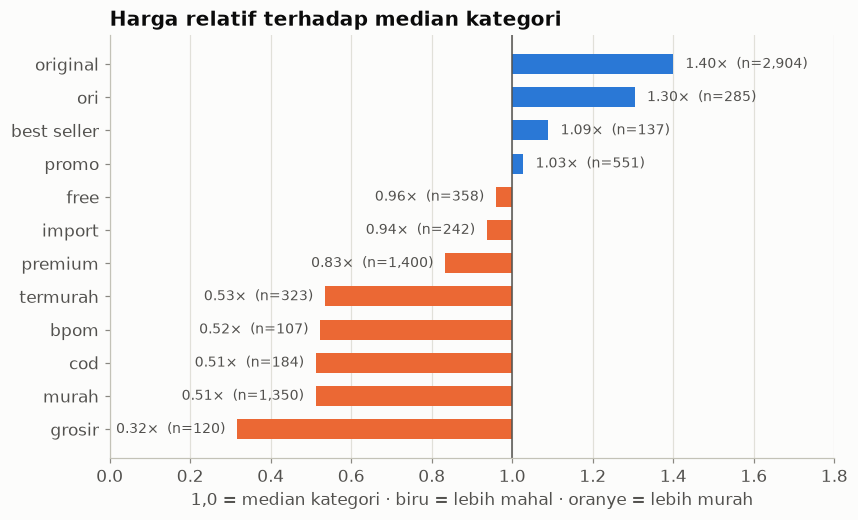

In [17]:
nama = df["nama_produk"].str.lower()
harga_relatif = df["harga"] / df.groupby("kategori")["harga"].transform("median")

kata = ["original", "ori", "import", "premium", "promo", "best seller", "free",
        "murah", "termurah", "cod", "bpom", "grosir", "ready"]
baris = []
for w in kata:
    ada = nama.str.contains(rf"\b{re.escape(w)}\b", regex=True)
    baris.append({"kata": w, "jumlah produk": int(ada.sum()),
                  "harga relatif": harga_relatif[ada].median()})
hasil = pd.DataFrame(baris)
hasil = hasil[hasil["jumlah produk"] >= 100].sort_values("harga relatif")

fig, ax = plt.subplots(figsize=(8.5, 5))
warna = [ps.BIRU if v >= 1 else ps.ORANYE for v in hasil["harga relatif"]]
ax.barh(hasil["kata"], hasil["harga relatif"] - 1, left=1, color=warna, height=0.6)
ax.axvline(1, color=ps.INK_2, linewidth=1)
for i, (v, n) in enumerate(zip(hasil["harga relatif"], hasil["jumlah produk"])):
    ax.text(v + (0.03 if v >= 1 else -0.03), i, f"{v:.2f}×  (n={n:,})",
            va="center", ha="left" if v >= 1 else "right", color=ps.INK_2, fontsize=9)
ax.set_xlim(0, 1.8)
ax.set_title("Harga relatif terhadap median kategori")
ax.set_xlabel("1,0 = median kategori · biru = lebih mahal · oranye = lebih murah")
plt.show()

Kata dengan kurang dari 100 produk tidak ditampilkan, karena sampelnya terlalu kecil untuk disimpulkan.

**Temuan:**

- **"Original" dan "Ori"** dipakai pada produk yang harganya sekitar 1,3-1,4 kali median kategorinya. Kata ini tampaknya memang sinyal harga: penjual menegaskan keaslian untuk membenarkan harga lebih tinggi.
- **"Murah", "Termurah", "COD", "Grosir"** konsisten di sekitar setengah median kategori atau lebih rendah — label ini jujur terhadap harganya.
- **"Premium" justru di bawah median** (sekitar 0,83×). Kata ini sudah kehilangan makna: dipakai begitu luas sampai tidak lagi membedakan produk mahal. Bagi penjual, memberi label "premium" bukan cara efektif untuk memposisikan produk.
- "BPOM" juga di bawah median. Kemungkinan karena label ini wajib dicantumkan pada kosmetik dan makanan murah untuk meyakinkan pembeli, bukan karena produknya mahal.

## 6. Dari eksplorasi ke skor peluang

Temuan di atas langsung membentuk rumus skor peluang di dashboard. Versi pertama rumus ini gagal saat diuji pada data asli, dan setiap kegagalannya bisa ditelusuri ke salah satu bagian di notebook ini:

| Versi pertama | Masalah | Temuan terkait | Versi sekarang |
|---|---|---|---|
| Segmen harga batas global | Elektronik semua "Premium", makanan semua "Ekonomis" | Bagian 2 | Kuartil di dalam tiap kategori |
| Permintaan dalam unit terjual | Segmen termurah selalu menang, karena barang murah laku lebih banyak | Bagian 2 | Nilai penjualan dalam Rupiah |
| Kepuasan = rating median | Median 4,9-5,0 di hampir semua segmen; selisihnya noise | Bagian 4 | Porsi pesaing dengan rating di bawah 4,7 |

Rumus akhirnya, dengan setiap komponen dalam z-score:

```
skor peluang = nilai penjualan − jumlah pesaing + porsi pesaing lemah
```

Hasil yang ditampilkan dashboard:

In [18]:
from src import opportunity

segmen = opportunity.ringkas_segmen(df)
tampil = segmen.head(8)[["kategori", "segmen_harga", "skor_peluang", "jumlah_produk",
                          "median_harga", "omzet_per_produk", "porsi_pesaing_lemah"]].copy()
tampil["median_harga"] = tampil["median_harga"].map(ps.rupiah)
tampil["omzet_per_produk"] = tampil["omzet_per_produk"].map(ps.rupiah)
tampil["porsi_pesaing_lemah"] = tampil["porsi_pesaing_lemah"].map("{:.0%}".format)
tampil

[opportunity] 48 kombinasi kategori x segmen dinilai


,kategori,segmen_harga,skor_peluang,jumlah_produk,median_harga,omzet_per_produk,porsi_pesaing_lemah
0,otomotif,Menengah,3.368,97,Rp72 rb,Rp44.0 jt,20%
1,otomotif,Super Premium,2.231,97,Rp1.3 jt,Rp94.3 jt,13%
2,olahraga,Menengah,1.177,122,Rp154 rb,Rp70.6 jt,10%
3,handphone,Ekonomis,1.003,229,Rp30 rb,Rp30.9 jt,12%
4,olahraga,Super Premium,0.990,122,Rp4.2 jt,Rp203.9 jt,6%
5,ibu & bayi,Ekonomis,0.974,102,Rp19 rb,Rp16.5 jt,12%
6,olahraga,Ekonomis,0.813,123,Rp40 rb,Rp65.5 jt,8%
7,fashion,Ekonomis,0.787,1634,Rp20 rb,Rp74.0 jt,13%


Satu pola yang perlu diwaspadai: segmen teratas didominasi **kategori kecil** seperti otomotif. Sebagian memang disengaja — pesaing yang sedikit menaikkan skor. Tapi jumlah pesaing di sini diukur dari *sampel*, bukan dari seluruh Tokopedia. Otomotif bisa tampak sepi pesaing hanya karena jarang ikut ter-scrape. Skor ini sebaiknya dibaca sebagai **daftar kandidat untuk diselidiki lebih lanjut**, bukan rekomendasi final.

## Ringkasan

| Temuan | Implikasi |
|---|---|
| Pencocokan potongan huruf membuat 9,5% produk salah kategori tanpa pesan error | Hasil yang "terlihat wajar" tetap harus diperiksa dengan membaca contohnya |
| Satu listing janggal menguasai separuh nilai pasar | Winsorizing per kategori sebelum menjumlahkan apa pun |
| Harga median antar kategori berbeda sampai 7 kali lipat | Segmen harga dihitung per kategori |
| Jakarta menampung sekitar separuh penjual; Bandung paling produktif per toko | Konsentrasi geografis kuat, dengan catatan bias sampel |
| Ada-tidaknya diskon berkaitan dengan penjualan, besar diskonnya tidak | Korelasi, bukan sebab-akibat |
| Rating berkorelasi negatif dengan penjualan | Rating mentah tidak layak jadi ukuran kepuasan |
| "Premium" dipakai produk di bawah harga median | Label yang terlalu umum kehilangan daya bedanya |

Analisis ulasan pembeli dilanjutkan di **notebook 02**.